In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Hierarchical_Interval_Halving import *
from optimal_hyperparameter import AMethod

### Reading the data. The algorithm expects a single 1D numpy array with no missing / NaN values

In [2]:
ts_arr = pd.read_csv('../give/data/path/here/file.csv')['col_name'].dropna().to_numpy() 
ts_name = 'Pressure- Sheet 1'

### Candidate set of hyperparameters (we need to choose the best from this set)

In [3]:
var_fracs_tuning = np.linspace(1e-2, 2e-1, num = 10)
window_lens_tuning = np.linspace(10, 200, num = 10, dtype = int)

### Functions for performing hyperparameter tuning and returning the best model

In [4]:
alpha_f_test_val = 0.05

def hyperparam_tuning_var(time_series, series_name, var_data, curr_frac):
    model = Hierarchical_Interval_Halving(noise_err = curr_frac*var_data, min_window_len = window_lens_tuning[0], max_degree = 2, \
                                      title = series_name, suppress_print = True, alpha_f_test = alpha_f_test_val)
    seg_count = model.train_model(time_series)
    return seg_count
    
def hyperparam_tuning_window(time_series, series_name, var_data, curr_window, opt_frac):
    model = Hierarchical_Interval_Halving(noise_err = opt_frac*var_data, min_window_len = int(curr_window), max_degree = 2, \
                                      title = series_name, suppress_print = True, alpha_f_test = alpha_f_test_val)
    seg_count = model.train_model(time_series)
    return seg_count

def segmentation_analysis(time_series, series_name):
    err_data = np.var(time_series)
    ###########################################
    # Parameter tuning for variance fraction
    ###########################################
    
    count_segments_var = np.array([hyperparam_tuning_var(time_series, series_name, err_data, frac)
                                   for frac in var_fracs_tuning])
    
    opt_var_frac = var_fracs_tuning[AMethod().get_elbow_point(var_fracs_tuning, count_segments_var)]
    ###########################################
    # Parameter tuning for window length
    ###########################################          
    count_segments_window = np.array([hyperparam_tuning_window(time_series, series_name, 
                                     err_data, tuning_len, opt_var_frac) for tuning_len in window_lens_tuning])
    
    opt_window_len = window_lens_tuning[AMethod().get_elbow_point(window_lens_tuning, count_segments_window)]
    
    ###########################################
    # Fitting the optimal model
    ###########################################
    model = Hierarchical_Interval_Halving(noise_err = opt_var_frac*err_data, ylabel = series_name.split('_')[-1], \
                                      max_degree = 2, min_window_len = opt_window_len, title = series_name, 
                                      suppress_print = True, alpha_f_test = alpha_f_test_val)
    model.train_model(time_series)        
    
    return model

### Fit the model (Using the hyperparameter tuning functions)

In [5]:
seg_model = segmentation_analysis(ts_arr, ts_name)

### Alternatively, fit the model by manually hard-coding the hyperparameters (noise_err and min_window_len) i.e. without using the hyperparameter tuning functions

### Smaller values of noise_err and min_window_len give more fine-grained segments and vice versa.

In [17]:
seg_model2 = Hierarchical_Interval_Halving(noise_err = 0.2, xlabel = 'Time (sec)', ylabel = 'Pressure (mbar)', \
                                      max_degree = 2, min_window_len = 100, title = 'Pressure Series', 
                                      suppress_print = True, alpha_f_test = 0.05)
seg_model2.train_model(ts_arr);

### Plot the results: Degree 0, Degree 1, ..., Degree n and Noisy Segments are indicated by different colors
###  For Degree 0 to Degree n segments, we display the fitted values. For Noisy segments, we display the original data since we are unable to get a good fit.

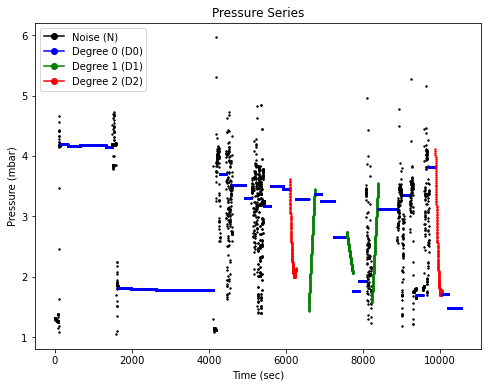

In [18]:
# NOTE- Increase figsize if the legend overlaps with the plot
plt.figure(figsize = (8,6)) 
seg_model2.plot_data_pred_intervals(linestyle = 'dotted', point_size = 2)
#plt.savefig('./filname.png', dpi = 1000)
plt.show()

### Print the segments and their labels

In [19]:
seg_model.return_intervals()

[[[0, 329], 'Noise (N)'],
 [[330, 1316], 'Degree 0 (D0)'],
 [[1317, 1645], 'Noise (N)'],
 [[1646, 3948], 'Degree 0 (D0)'],
 [[3949, 4606], 'Noise (N)'],
 [[4607, 4935], 'Degree 0 (D0)'],
 [[4936, 5594], 'Noise (N)'],
 [[5595, 5923], 'Degree 0 (D0)'],
 [[5924, 6252], 'Noise (N)'],
 [[6253, 6581], 'Degree 0 (D0)'],
 [[6582, 6910], 'Degree 2 (D2)'],
 [[6911, 7568], 'Degree 0 (D0)'],
 [[7569, 7897], 'Degree 1 (D1)'],
 [[7898, 8226], 'Noise (N)'],
 [[8227, 8884], 'Degree 2 (D2)'],
 [[8885, 9213], 'Noise (N)'],
 [[9214, 9542], 'Degree 2 (D2)'],
 [[9543, 9871], 'Noise (N)'],
 [[9872, 10200], 'Degree 2 (D2)'],
 [[10201, 10529], 'Degree 0 (D0)']]